# electrification cement NPV simulation

Run the electrification cement Monte Carlo simulation and visualize the resulting NPV distribution.

The summary also reports how many simulations have non-negative NPV (NPV >= 0) and how many have negative NPV.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from cement.cement_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_cement_results,
)

from npv_summary import summarize_metric_signs


In [2]:
TECHNOLOGY = 'electrification'
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_cement_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_t,lifetime_years,capex_eur_per_t,fixed_opex_eur_per_t,variable_opex_eur_per_t,fuel_consumption_mwh_th_per_t,...,annual_revenue_eur,annual_fixed_opex_eur,annual_variable_opex_eur,annual_fuel_cost_eur,annual_electricity_cost_eur,annual_emissions_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_t,levelized_net_margin_eur_per_t
0,0,electrification,absolute,not_applicable,1000000.0,25.0,208.698817,25.157297,9.410140,0.0,...,150000000.0,2.515730e+07,9.410140e+06,0.0,2.042967e+08,3.032936e+07,-1.191935e+08,-1.481063e+09,1.067478e+07,-138.744144
1,1,electrification,absolute,not_applicable,1000000.0,25.0,170.893615,17.306545,8.881603,0.0,...,150000000.0,1.730655e+07,8.881603e+06,0.0,2.126920e+08,3.207678e+07,-1.209569e+08,-1.462082e+09,1.067478e+07,-136.966035
2,2,electrification,absolute,not_applicable,1000000.0,25.0,225.287484,19.895200,8.951326,0.0,...,150000000.0,1.989520e+07,8.951326e+06,0.0,1.837474e+08,3.553061e+07,-9.812457e+07,-1.272745e+09,1.067478e+07,-119.229225
3,3,electrification,absolute,not_applicable,1000000.0,25.0,196.719996,23.150093,6.219574,0.0,...,150000000.0,2.315009e+07,6.219574e+06,0.0,1.964091e+08,3.461011e+07,-1.103889e+08,-1.375097e+09,1.067478e+07,-128.817413
4,4,electrification,absolute,not_applicable,1000000.0,25.0,252.930094,24.463389,9.053570,0.0,...,150000000.0,2.446339e+07,9.053570e+06,0.0,1.751118e+08,2.851207e+07,-8.714079e+07,-1.183138e+09,1.067478e+07,-110.834968


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
levelized_net_margin_eur_per_t = results["levelized_net_margin_eur_per_t"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        levelized_net_margin_eur_per_t.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "Levelized net margin EUR/t cement"
        ),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,Levelized net margin EUR/t cement
count,100000.000000,100000.000000
mean,-1115.124266,-104.463480
std,372.921702,34.934850
min,-2059.431223,-192.925003
5%,-1681.465829,-157.517666
50%,-1137.567444,-106.565929
95%,-461.954651,-43.275348
max,30.072229,2.817130


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),6,0.00006
1,Negative (NPV < 0),99994,0.99994


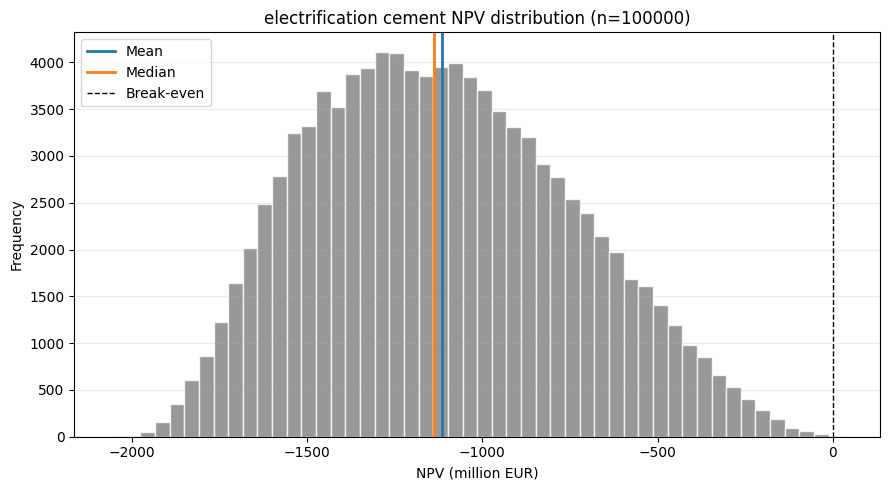

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(npv_million_eur, bins=50, color="tab:gray", edgecolor="white", alpha=0.8)
ax.axvline(npv_million_eur.mean(), color="tab:blue", linewidth=2, label="Mean")
ax.axvline(npv_million_eur.median(), color="tab:orange", linewidth=2, label="Median")
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrification cement NPV distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("NPV (million EUR)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


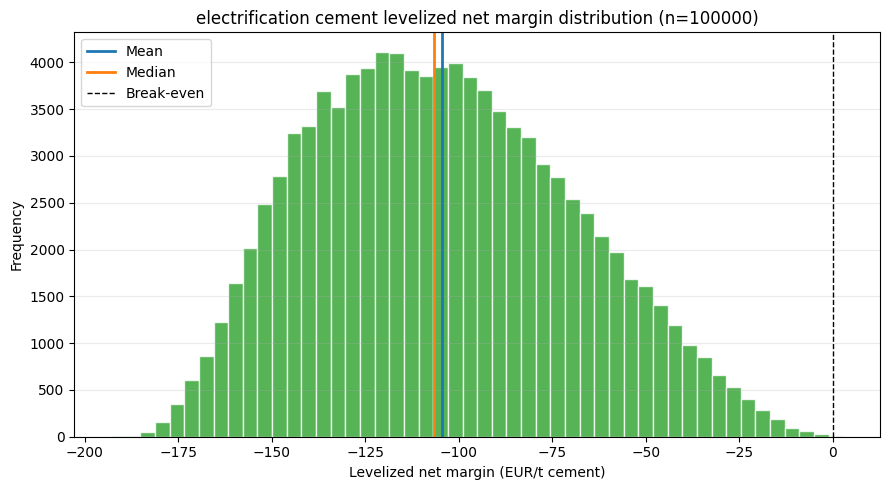

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    levelized_net_margin_eur_per_t,
    bins=50,
    color="tab:green",
    edgecolor="white",
    alpha=0.8,
)
ax.axvline(
    levelized_net_margin_eur_per_t.mean(),
    color="tab:blue",
    linewidth=2,
    label="Mean",
)
ax.axvline(
    levelized_net_margin_eur_per_t.median(),
    color="tab:orange",
    linewidth=2,
    label="Median",
)
ax.axvline(0, color="black", linewidth=1, linestyle="--", label="Break-even")

ax.set_title(f"electrification cement levelized net margin distribution (n={SAMPLE_SIZE})")
ax.set_xlabel("Levelized net margin (EUR/t cement)")
ax.set_ylabel("Frequency")
ax.grid(axis="y", alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()


In [6]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur",
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             150.000000
annual_fixed_opex_eur           19.986132
annual_variable_opex_eur         7.802609
annual_fuel_cost_eur             0.000000
annual_electricity_cost_eur    174.552662
annual_emissions_cost_eur       32.011967
annual_net_cash_flow_eur       -84.353370
Name: Mean annual value, million EUR, dtype: float64